                                         CROP DISEASE PREDICTION

In [14]:
from tokenize import Ignore

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

import warnings
warnings.filterwarnings("ignore")


In [15]:
dataset_path = "/Users/mohammadakifakhtar/PROGRAM/Jupyter/Deep_learning_ml/CNN/Crop_disease_detection/PlantVillage"

In [16]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    #image_size=(224,224),
    image_size=(128,128),

    batch_size=64
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    #image_size=(224,224),
    image_size=(128,128),
    batch_size=64
)

# Save these BEFORE preprocessing
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print(num_classes)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
15


In [35]:
for images, labels in train_ds.take(1):
    print("Min :", images.numpy().min())
    print("Max :", images.numpy().max())
    print("Dtype :", images.dtype)

Min : 0.0
Max : 248.75
Dtype : <dtype: 'float32'>


2026-07-19 15:31:31.399932: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
class_names = train_ds.class_names

print(class_names)
print("Number of Classes:", len(class_names))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of Classes: 15


In [19]:
import os

print(os.path.exists(dataset_path))
print(os.listdir(dataset_path)[:10])

True
['Tomato_healthy', 'Potato___Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Early_blight', '.DS_Store', 'Tomato__Target_Spot', 'Potato___Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Septoria_leaf_spot']


Display Sample Images

2026-07-19 15:27:55.237190: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


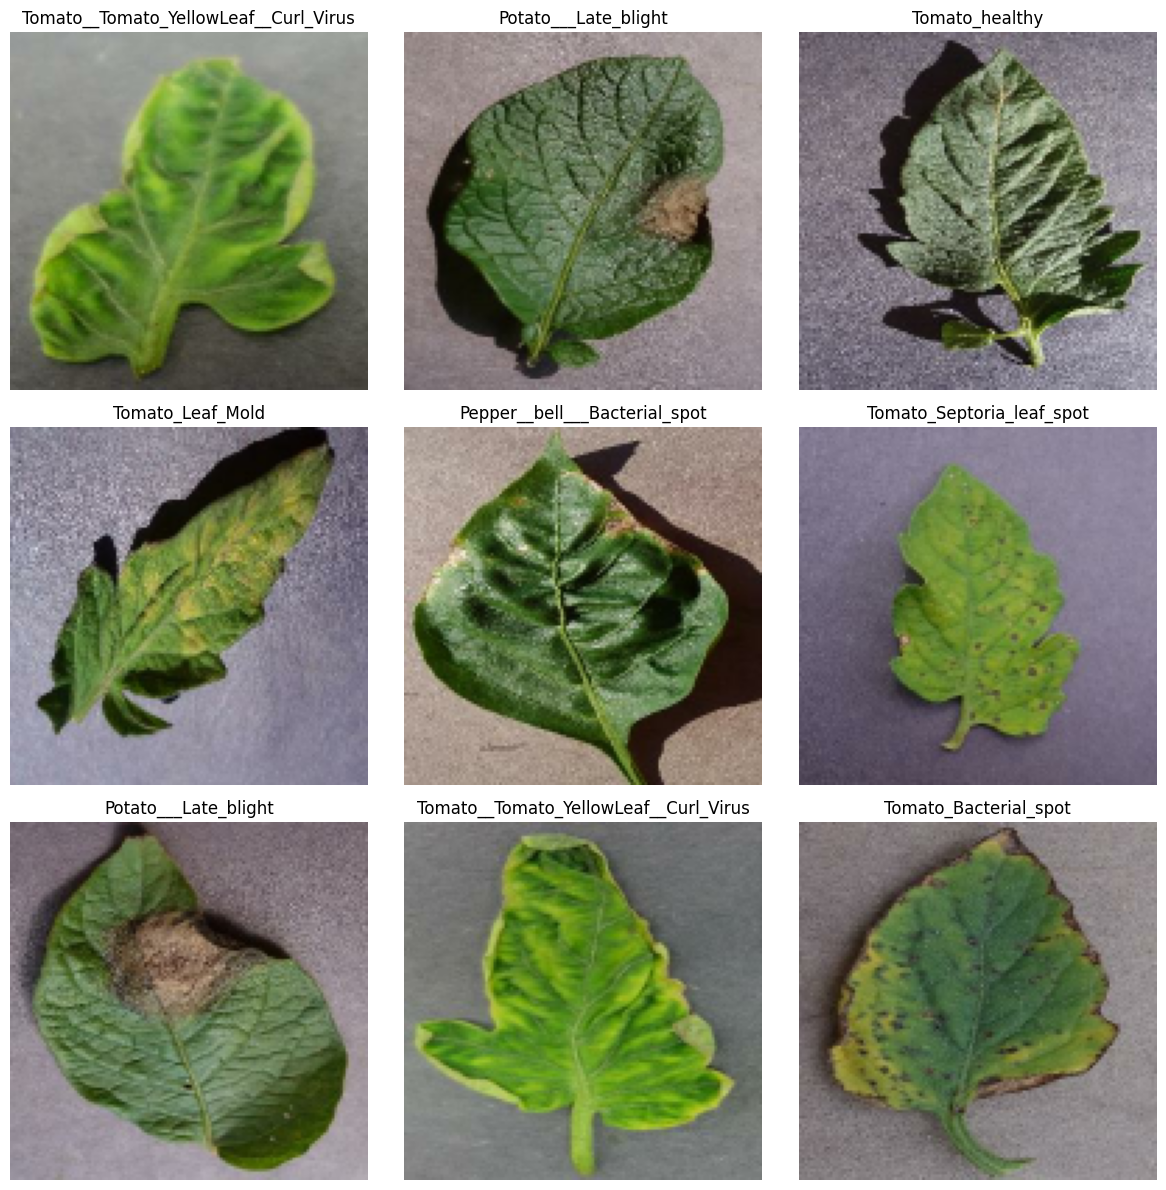

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

 Check Pixel Value Range

In [21]:
for images, labels in train_ds.take(1):

    print("Minimum Pixel:", images.numpy().min())
    print("Maximum Pixel:", images.numpy().max())

Minimum Pixel: 0.0
Maximum Pixel: 255.0


2026-07-19 12:44:25.924196: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Count Images per Class

In [22]:
import os

dataset_path = "/Users/mohammadakifakhtar/PROGRAM/Jupyter/Deep_learning_ml/CNN/Crop_disease_detection/PlantVillage"

for folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        count = len([
            file for file in os.listdir(folder_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        print(f"{folder:<45} {count}")

Pepper__bell___Bacterial_spot                 997
Pepper__bell___healthy                        1478
Potato___Early_blight                         1000
Potato___Late_blight                          1000
Potato___healthy                              152
Tomato_Bacterial_spot                         2127
Tomato_Early_blight                           1000
Tomato_Late_blight                            1909
Tomato_Leaf_Mold                              952
Tomato_Septoria_leaf_spot                     1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
Tomato__Target_Spot                           1404
Tomato__Tomato_YellowLeaf__Curl_Virus         3208
Tomato__Tomato_mosaic_virus                   373
Tomato_healthy                                1591


Plot Class Distribution

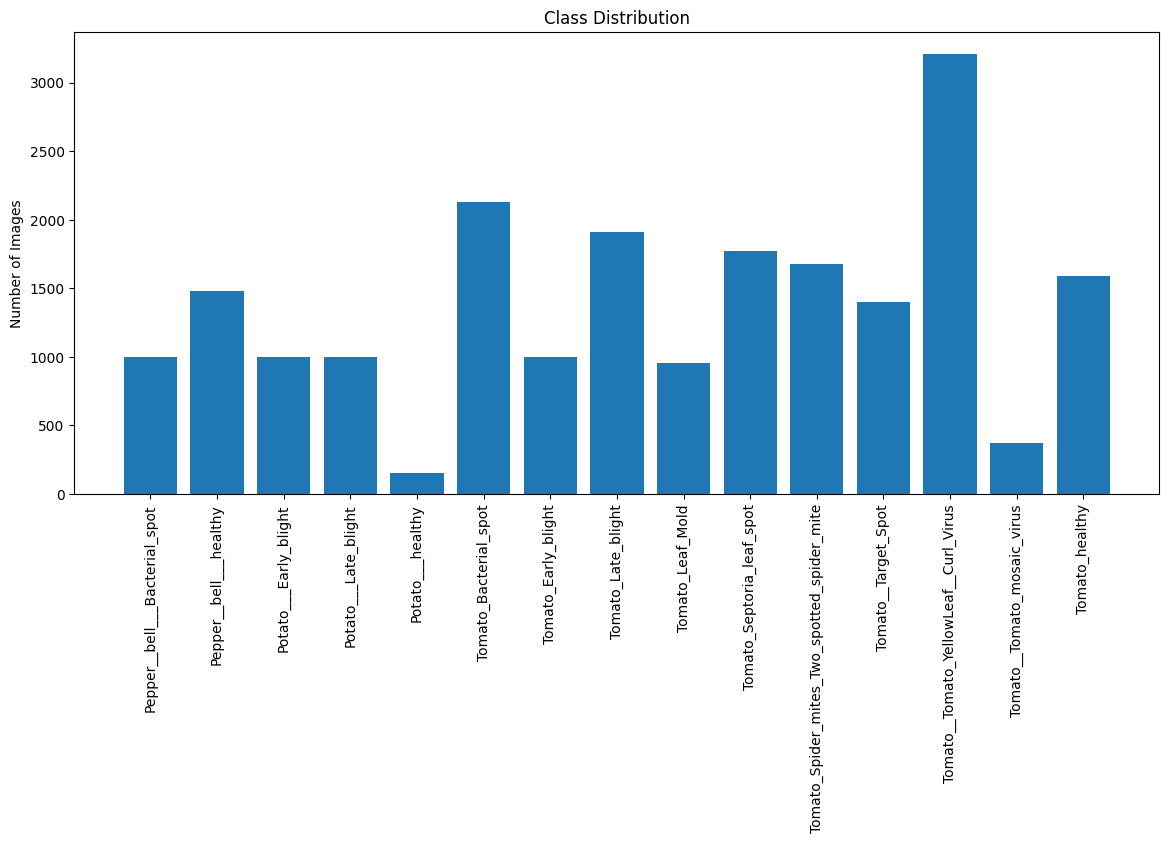

In [23]:
import os

classes = []
counts = []

for folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        classes.append(folder)
        counts.append(len(os.listdir(folder_path)))

plt.figure(figsize=(14,6))
plt.bar(classes, counts)
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

In [24]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [25]:
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

Verify Normalization

In [26]:
for images, labels in train_ds.take(1):
    print("Minimum Pixel :", images.numpy().min())
    print("Maximum Pixel :", images.numpy().max())

Minimum Pixel : 0.0
Maximum Pixel : 0.987255


2026-07-19 12:44:26.205297: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Cache Dataset

In [27]:
train_ds = train_ds.cache()
val_ds = val_ds.cache()

Prefetch Dataset
Allows CPU and GPU to work simultaneously.

In [28]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

 Data Augmentation

In [29]:
#Deep learning models perform much better when they see slightly modified images during training.


data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.RandomContrast(0.1)

])

Visualize Augmented Images

2026-07-19 12:44:26.285362: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-07-19 12:44:27.242331: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


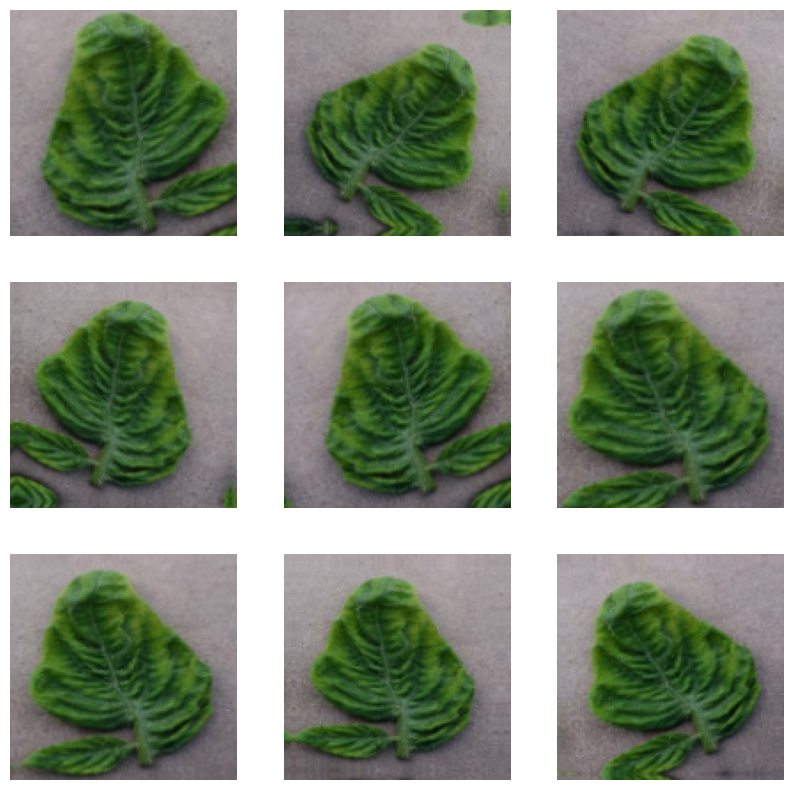

In [30]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        augmented = data_augmentation(
            tf.expand_dims(first_image,0)
        )

        plt.imshow(augmented[0])

        plt.axis("off")

plt.show()

Check Dataset Pipeline

In [31]:
print(train_ds)

print(val_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


Build CNN Model

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.layers import Dropout,BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D


In [36]:
model = Sequential([

    Input(shape=(128,128,3)),

    data_augmentation,

    Conv2D(32, (3,3), padding="same", activation="relu"),
    BatchNormalization(),

    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),

    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), padding="same", activation="relu"),
    BatchNormalization(),

    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(256, (3,3), padding="same", activation="relu"),
    BatchNormalization(),

    MaxPooling2D((2,2)),
    Dropout(0.30),


    #Flatten(),
    #Dense(512,activation="relu"),
    #Dropout(0.5),
    #Dense(num_classes,activation="softmax")

    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.50),
    Dense(num_classes, activation="softmax")

])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,983 (1.75 MB)

 Trainable params: 459,023 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

Compile Model

In [37]:
from tensorflow.keras.optimizers import Adam

model.compile(
    #optimizer="adam",
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]

)

Callbacks

In [38]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

Train the Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=29,
    callbacks=[early_stop,reduce_lr,checkpoint,]
)

Epoch 1/29


2026-07-19 12:46:22.477460: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


258/258 ━━━━━━━━━━━━━━━━━━━━ 129s 481ms/step - accuracy: 0.5573 - loss: 1.5007 - val_accuracy: 0.1272 - val_loss: 9.7736 - learning_rate: 0.0010
Epoch 2/29
258/258 ━━━━━━━━━━━━━━━━━━━━ 120s 465ms/step - accuracy: 0.7152 - loss: 0.9625 - val_accuracy: 0.2183 - val_loss: 7.3679 - learning_rate: 0.0010
Epoch 3/29
258/258 ━━━━━━━━━━━━━━━━━━━━ 108s 421ms/step - accuracy: 0.7907 - loss: 0.7073 - val_accuracy: 0.6639 - val_loss: 1.5034 - learning_rate: 0.0010
Epoch 4/29
258/258 ━━━━━━━━━━━━━━━━━━━━ 109s 424ms/step - accuracy: 0.8239 - loss: 0.5719 - val_accuracy: 0.6133 - val_loss: 2.1436 - learning_rate: 0.0010
Epoch 5/29
258/258 ━━━━━━━━━━━━━━━━━━━━ 111s 428ms/step - accuracy: 0.8609 - loss: 0.4520 - val_accuracy: 0.8522 - val_loss: 0.5504 - learning_rate: 0.0010
Epoch 6/29
258/258 ━━━━━━━━━━━━━━━━━━━━ 111s 429ms/step - accuracy: 0.8818 - loss: 0.3768 - val_accuracy: 0.7027 - val_loss: 1.4267 - learning_rate: 0.0010
Epoch 7/29
258/258 ━━━━━━━━━━━━━━━━━━━━ 114s 440ms/step - accuracy: 0.8982 

Plot Accuracy

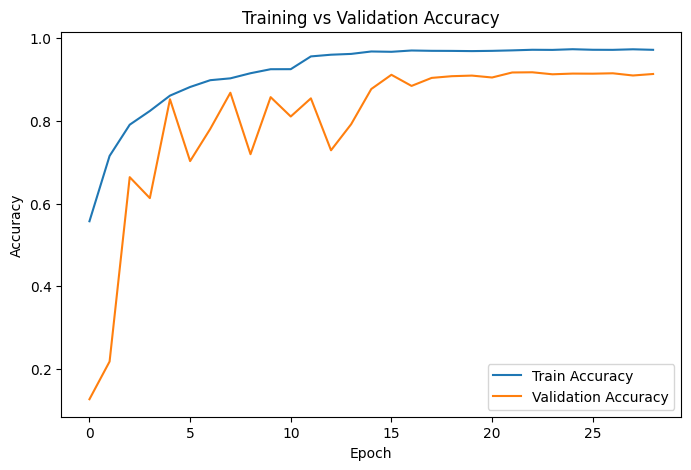

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Train Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

Plot Loss

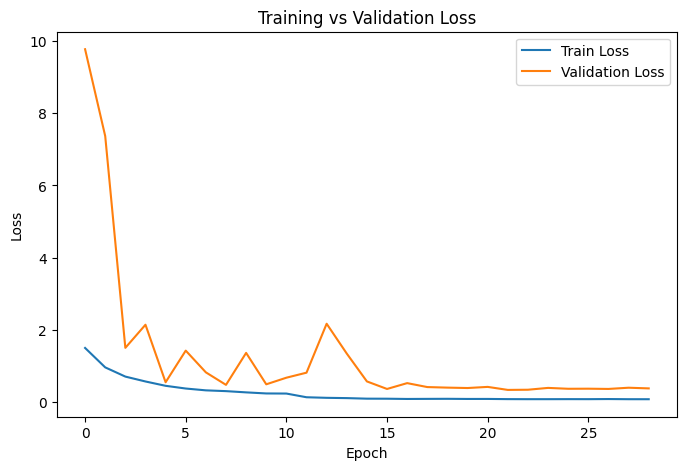

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

Evaluate Model

In [42]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9169 - loss: 0.3385
Validation Loss : 0.33851519227027893
Validation Accuracy : 0.9168887734413147


Get Predictions

In [45]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2026-07-19 13:59:59.796700: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[195   2   2   0   0   1   0   0   0   0   0   0   0   0   0]
 [  0 301   0   0   1   0   0   0   0   0   0   0   0   0   0]
 [  0   0 189   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   7 175   4   0   0   1   0   0   0   0   0   0   1]
 [  0   0   0   1  30   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   1   1 422   6   0   0   2   2   6   1   0   0]
 [  0   0   5   4   0   0 179   1   0   1   0   0   0   0   1]
 [  1   1  19  13   0   1  10 279   2   2   2   0   0   1  10]
 [  0   7   0   0   0   0   0   0 174   2   0   0   0   0   2]
 [  0   3  11   0   0   0   5   0   2 369   1   0   0   1   0]
 [  0   1   0   1   2   0   0   0   0   0 255   0   0   3  70]
 [  0   1   1   1   1   0   1   0   0   2  35 163   0   0  56]
 [  0   0   0   0   0   6   0   0   0   0   3   0 625   0   0]
 [  0   2   0   0   0   0   0   0   0   0   0   0   0  67   9]
 [  0   0   0   1   0   0   0   0   0   0   0   0   0   0 361]]


Plot Confusion Matrix

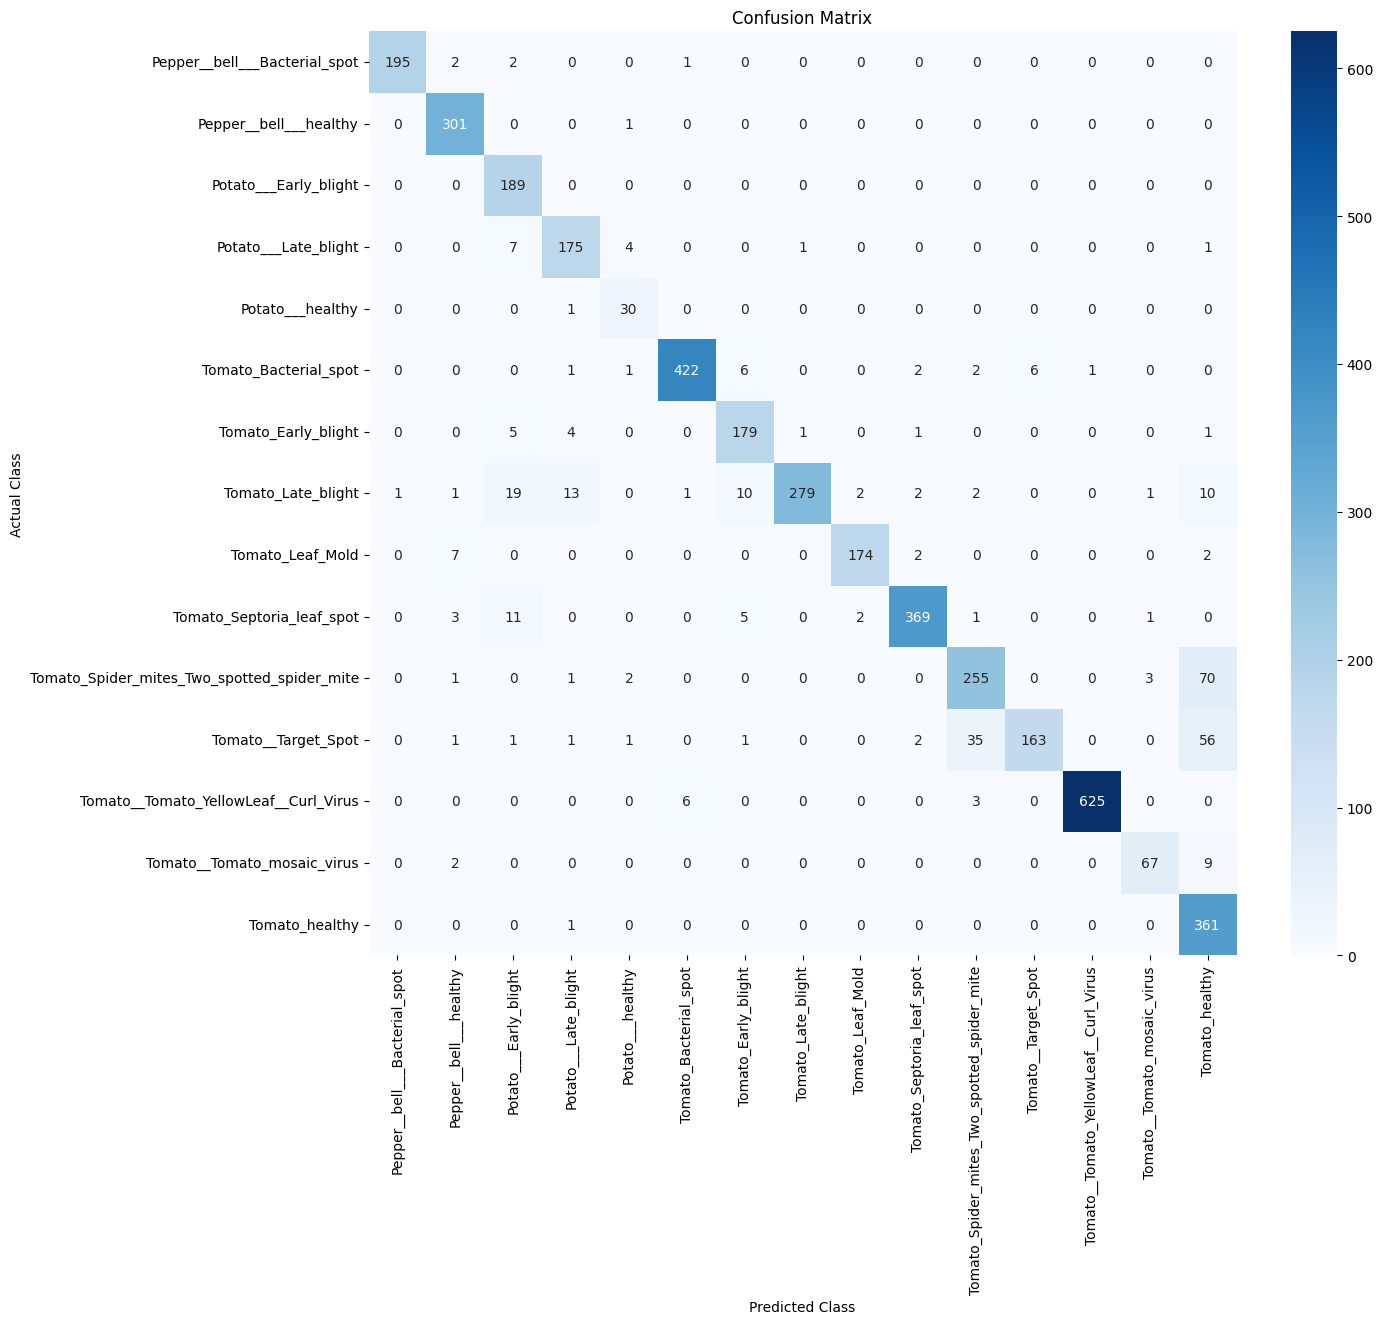

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

Classification Report

In [48]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.97      0.98       200
                     Pepper__bell___healthy       0.95      1.00      0.97       302
                      Potato___Early_blight       0.81      1.00      0.89       189
                       Potato___Late_blight       0.89      0.93      0.91       188
                           Potato___healthy       0.77      0.97      0.86        31
                      Tomato_Bacterial_spot       0.98      0.96      0.97       441
                        Tomato_Early_blight       0.89      0.94      0.91       191
                         Tomato_Late_blight       0.99      0.82      0.90       341
                           Tomato_Leaf_Mold       0.98      0.94      0.96       185
                  Tomato_Septoria_leaf_spot       0.98      0.94      0.96       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.86      0.77

Overall Accuracy

In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9168887811969954


Precision

In [50]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Precision :", precision)

Precision : 0.928265002212947


Save Model

In [43]:
model.save("crop_disease_model.keras")

                                                 TESTING IN NEW IMAGE

In [6]:
from tensorflow.keras.models import load_model

model = load_model("leaf_disease_model.keras")

2026-07-19 17:09:32.521447: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-07-19 17:09:32.521480: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-19 17:09:32.521485: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-19 17:09:32.521522: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-19 17:09:32.521542: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Load a New Leaf Image

In [7]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/Users/mohammadakifakhtar/PROGRAM/Jupyter/Deep_learning_ml/CNN/Crop_disease_detection/leaf1_test.jpeg"

img = image.load_img(
    img_path,
    target_size=(128,128)      # Use (224,224) if your model was trained on 224×224
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)



Predict

In [8]:
prediction = model.predict(img_array)

2026-07-19 17:09:43.405352: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


Get Predicted Class

In [9]:
predicted_class = np.argmax(prediction)

print(predicted_class)

11


Convert Index to Disease Name

In [17]:
print("Disease :", class_names[predicted_class])

Disease : Tomato__Target_Spot


 Prediction Confidence

In [18]:
confidence = np.max(prediction) * 100

print(f"Confidence : {confidence:.2f}%")

Confidence : 99.74%


Display the Image with Prediction

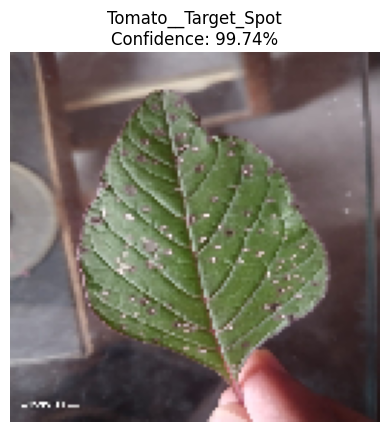

In [79]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")

plt.title(
    f"{class_names[predicted_class]}\nConfidence: {confidence:.2f}%"
)

plt.show()

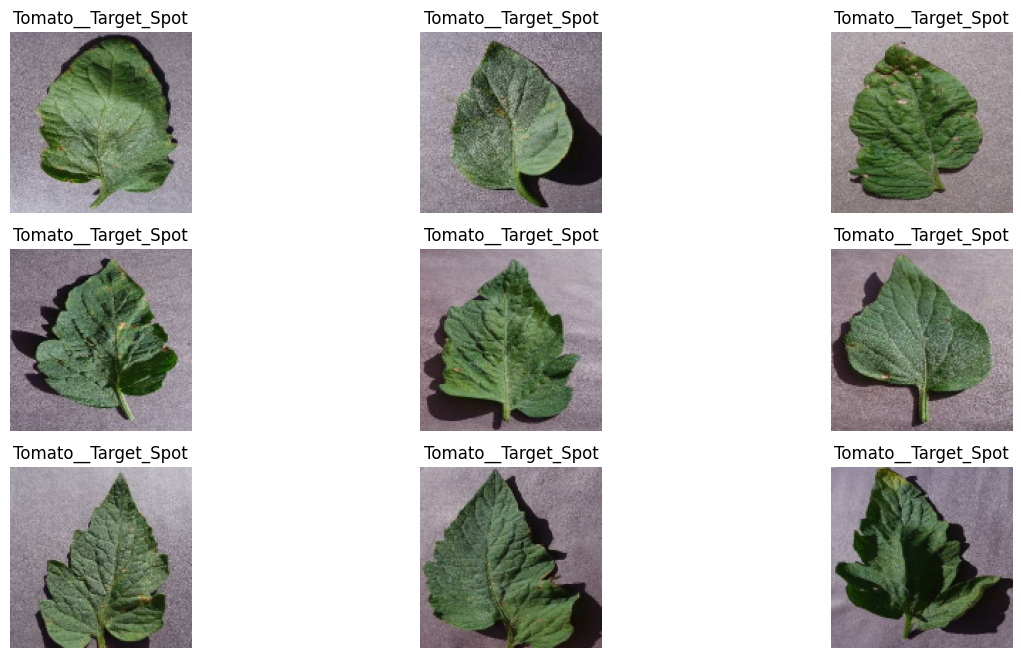

In [80]:
import matplotlib.pyplot as plt

target_class = predicted_class

plt.figure(figsize=(15,8))

count = 1

for images, labels in train_ds:
    for i in range(len(labels)):
        if labels[i] == target_class:
            plt.subplot(3,3,count)
            plt.imshow(images[i].numpy().astype(np.uint8))
            plt.title(class_names[target_class])
            plt.axis("off")
            count += 1
            if count > 9:
                break

    if count > 9:
        break
plt.show()